# Step 03 — Preprocessing: Lee et al. (2013) Method
**Project:** ENSO-BSISO Self-Supervised Learning  
**Author:** Jiayi (jh9141@nyu.edu)

This notebook preprocesses ERA5 fields following **Lee et al. (2013)** to isolate the
intraseasonal (BSISO) signal before feeding data into the Siamese CNN.

**Three preprocessing steps (in order):**
1. **Remove annual cycle** — subtract the climatological daily mean (base period 1981–2010)
2. **Remove interannual variability** — subtract the preceding 120-day running mean
3. **Normalize** — divide by area-averaged temporal standard deviation

**Inputs (from Google Drive `data/raw/`):**
- `u850_v850_MJJAS_YYYY_YYYY.nc` × 5 chunks (from Notebook 01b)
- `OLR_MJJAS_1979_2023.nc` (from Notebook 01b)
- `labels.csv` — BSISO phase + ENSO category (from Notebook 02)

**Output (to `data/processed/`):**
- `X_July_lee.npy` — shape (N, 3, 31, 51), float32
- `labels_aligned_lee.csv` — N rows aligned to X_July_lee
- `norm_stats_lee.json` — normalization scalars per channel

**Note on 120-day window:**  
For July 1, only ~61 days of preceding data are available (May + June).
The running mean uses `min_periods=1` — it uses whatever preceding days exist.
The full 120-day window is satisfied by late August.

## Cell 1 — Mount Google Drive + Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import numpy as np
import pandas as pd
import xarray as xr

PROJECT_DIR   = '/content/drive/MyDrive/BSISO_SSL_Project'
RAW_DIR       = f'{PROJECT_DIR}/data/raw'
PROCESSED_DIR = f'{PROJECT_DIR}/data/processed'

os.makedirs(PROCESSED_DIR, exist_ok=True)

print('Google Drive mounted.')
print('MJJAS ERA5 files in raw/:')
for f in sorted(os.listdir(RAW_DIR)):
    if 'MJJAS' in f:
        mb = os.path.getsize(f'{RAW_DIR}/{f}') / 1e6
        print(f'  {f}  ({mb:.0f} MB)')

Mounted at /content/drive
Google Drive mounted.
MJJAS ERA5 files in raw/:
  OLR_MJJAS_1979_2023.nc  (28 MB)
  u850_v850_MJJAS_1979_1989.nc  (14 MB)
  u850_v850_MJJAS_1990_1999.nc  (13 MB)
  u850_v850_MJJAS_2000_2009.nc  (13 MB)
  u850_v850_MJJAS_2010_2019.nc  (13 MB)
  u850_v850_MJJAS_2020_2023.nc  (5 MB)


## Cell 2 — Load MJJAS ERA5 Wind (u850, v850)

In [2]:
wind_files = sorted([
    f'{RAW_DIR}/{f}' for f in os.listdir(RAW_DIR)
    if f.startswith('u850_v850_MJJAS') and f.endswith('.nc')
])

print(f'Found {len(wind_files)} wind chunks:')
for f in wind_files:
    print(f'  {os.path.basename(f)}')

datasets = []
for f in wind_files:
    ds = xr.open_dataset(f).squeeze('pressure_level', drop=True)
    datasets.append(ds)

ds_wind = xr.concat(datasets, dim='valid_time').sortby('valid_time')

lats  = ds_wind.latitude.values
lons  = ds_wind.longitude.values
n_lat = len(lats)
n_lon = len(lons)

wind_times = pd.DatetimeIndex(ds_wind.valid_time.values).normalize()

print(f'\nCombined wind: {len(wind_times)} days')
print(f'Date range:    {wind_times[0].date()} to {wind_times[-1].date()}')
print(f'Grid:          {n_lat} lat x {n_lon} lon')
print(f'Months:        {sorted(set(wind_times.month))}')

Found 5 wind chunks:
  u850_v850_MJJAS_1979_1989.nc
  u850_v850_MJJAS_1990_1999.nc
  u850_v850_MJJAS_2000_2009.nc
  u850_v850_MJJAS_2010_2019.nc
  u850_v850_MJJAS_2020_2023.nc

Combined wind: 6885 days
Date range:    1979-05-01 to 2023-09-30
Grid:          31 lat x 51 lon
Months:        [5, 6, 7, 8, 9]


## Cell 3 — Load MJJAS ERA5 OLR

In [3]:
ds_olr    = xr.open_dataset(f'{RAW_DIR}/OLR_MJJAS_1979_2023.nc')
olr_times = pd.DatetimeIndex(ds_olr.valid_time.values).normalize()

print(f'OLR: {len(olr_times)} days')
print(f'Date range: {olr_times[0].date()} to {olr_times[-1].date()}')
print(f'Months: {sorted(set(olr_times.month))}')
print(f'Raw ttr range: [{float(ds_olr["ttr"].min()):.0f}, {float(ds_olr["ttr"].max()):.0f}] J/m2')

OLR: 6885 days
Date range: 1979-05-01 to 2023-09-30
Months: [5, 6, 7, 8, 9]
Raw ttr range: [-1480402, -265269] J/m2


## Cell 4 — Load Labels

In [4]:
df_labels = pd.read_csv(f'{RAW_DIR}/labels.csv', parse_dates=['date'])
df_labels['date'] = df_labels['date'].dt.normalize()

print(f'Labels: {len(df_labels)} rows')
print(f'Date range: {df_labels["date"].min().date()} to {df_labels["date"].max().date()}')
print(f'\nPhase distribution:')
print(df_labels['bsiso_phase'].value_counts().sort_index())
print(f'\nENSO distribution:')
print(df_labels['enso_category'].value_counts())

Labels: 1333 rows
Date range: 1981-07-01 to 2023-07-31

Phase distribution:
bsiso_phase
1    192
2    184
3    195
4    125
5    135
6    169
7    134
8    199
Name: count, dtype: int64

ENSO distribution:
enso_category
Neutral    775
La Nina    341
El Nino    217
Name: count, dtype: int64


## Cell 5 — Build Raw MJJAS Arrays

Load all MJJAS data into numpy. These are the raw (un-normalized) fields
that the three preprocessing steps will operate on.
Shape: (T_mjjas, lat, lon) per variable, where T_mjjas = 45 years x ~153 days.

In [5]:
mjjas_dates = wind_times.intersection(olr_times).sort_values()

print(f'Common MJJAS dates: {len(mjjas_dates)}')
print(f'Date range: {mjjas_dates[0].date()} to {mjjas_dates[-1].date()}')

wind_date_to_idx = {d: i for i, d in enumerate(wind_times)}
olr_date_to_idx  = {d: i for i, d in enumerate(olr_times)}

wind_idx = np.array([wind_date_to_idx[d] for d in mjjas_dates])
olr_idx  = np.array([olr_date_to_idx[d]  for d in mjjas_dates])

print('Loading arrays into memory ...')
u_raw   = ds_wind['u'].values[wind_idx].astype(np.float32)
v_raw   = ds_wind['v'].values[wind_idx].astype(np.float32)
olr_raw = (-ds_olr['ttr'].values[olr_idx]).astype(np.float32)

T = len(mjjas_dates)
print(f'u_raw shape:   {u_raw.shape}')
print(f'v_raw shape:   {v_raw.shape}')
print(f'olr_raw shape: {olr_raw.shape}')
print(f'Estimated memory: {3 * T * n_lat * n_lon * 4 / 1e6:.1f} MB')

Common MJJAS dates: 6885
Date range: 1979-05-01 to 2023-09-30
Loading arrays into memory ...
u_raw shape:   (6885, 31, 51)
v_raw shape:   (6885, 31, 51)
olr_raw shape: (6885, 31, 51)
Estimated memory: 130.6 MB


## Cell 6 — Step 1: Remove Annual Cycle

Lee et al. (2013): anomalies were obtained by removing the slow annual cycle
(the annual mean and the first three harmonics of climatological annual variation).

Implementation: For each calendar day-of-year (DOY), compute the mean across all
years in the base period 1981-2010, then subtract it from every occurrence of that DOY.
Base period: 1981-2010 (30 years), same as Lee et al.

In [6]:
BASE_START = 1981
BASE_END   = 2010

years     = mjjas_dates.year.values
doys      = mjjas_dates.day_of_year.values
base_mask = (years >= BASE_START) & (years <= BASE_END)

print(f'Base period days available: {base_mask.sum()}')

def remove_annual_cycle(raw, doys, base_mask):
    """Subtract daily climatology (mean over base period) for each DOY."""
    anom = raw.copy()
    for doy in np.unique(doys):
        base_idx = np.where((doys == doy) & base_mask)[0]
        all_idx  = np.where(doys == doy)[0]
        if len(base_idx) == 0:
            continue
        clim = raw[base_idx].mean(axis=0)  # (lat, lon)
        anom[all_idx] -= clim
    return anom

print('Removing annual cycle from u850 ...')
u_anom   = remove_annual_cycle(u_raw,   doys, base_mask)
print('Removing annual cycle from v850 ...')
v_anom   = remove_annual_cycle(v_raw,   doys, base_mask)
print('Removing annual cycle from OLR  ...')
olr_anom = remove_annual_cycle(olr_raw, doys, base_mask)

print(f'\nPost-step-1 mean over base period (should be ~0):')
print(f'  u850: {u_anom[base_mask].mean():+.6f}')
print(f'  v850: {v_anom[base_mask].mean():+.6f}')
print(f'  OLR:  {olr_anom[base_mask].mean():+.6f}')

Base period days available: 4590
Removing annual cycle from u850 ...
Removing annual cycle from v850 ...
Removing annual cycle from OLR  ...

Post-step-1 mean over base period (should be ~0):
  u850: +0.000000
  v850: -0.000000
  OLR:  +0.006816


## Cell 7 — Step 2: Remove Interannual Variability (120-day Running Mean)

Lee et al. (2013): the interannual variability was removed by subtracting the
running mean of the preceding 120 days.

closed='left' excludes the current day so the window is strictly preceding.
min_periods=1 prevents NaN when fewer than 120 days are available.

In [7]:
WINDOW = 120

def remove_running_mean(anom_3d, dates, window=120):
    """
    Subtract the preceding window-day running mean.
    Shape: (T, lat, lon). Flattened spatially for efficiency.
    """
    T, nlat, nlon = anom_3d.shape
    flat     = anom_3d.reshape(T, nlat * nlon)
    df       = pd.DataFrame(flat.astype(np.float64), index=dates)
    run_mean = df.rolling(window=window, min_periods=1, closed='left').mean().values
    return (flat - run_mean).reshape(T, nlat, nlon).astype(np.float32)

print('Removing 120-day running mean from u850 ...')
u_iso   = remove_running_mean(u_anom,   mjjas_dates, WINDOW)
print('Removing 120-day running mean from v850 ...')
v_iso   = remove_running_mean(v_anom,   mjjas_dates, WINDOW)
print('Removing 120-day running mean from OLR  ...')
olr_iso = remove_running_mean(olr_anom, mjjas_dates, WINDOW)

# Show window coverage for July days
sample_year   = 2000
july_in_year  = mjjas_dates[(mjjas_dates.month == 7) & (mjjas_dates.year == sample_year)]
print(f'\nPreceding days available for July {sample_year}:')
for d in list(july_in_year[:3]) + list(july_in_year[-3:]):
    idx   = np.where(mjjas_dates == d)[0][0]
    avail = min(idx, WINDOW)
    print(f'  {d.date()}: {avail}/{WINDOW} days ({avail/WINDOW*100:.0f}%)')

Removing 120-day running mean from u850 ...
Removing 120-day running mean from v850 ...
Removing 120-day running mean from OLR  ...

Preceding days available for July 2000:
  2000-07-01: 120/120 days (100%)
  2000-07-02: 120/120 days (100%)
  2000-07-03: 120/120 days (100%)
  2000-07-29: 120/120 days (100%)
  2000-07-30: 120/120 days (100%)
  2000-07-31: 120/120 days (100%)


## Cell 8 — Step 3: Normalize by Area-Averaged Temporal Std

Lee et al. (2013): anomaly fields were normalized by area-averaged temporal
standard deviation over the ASM region.

For each variable:
  1. Compute temporal std at every grid point over the base period -> std_map (lat, lon)
  2. Average std_map over the domain -> one scalar
  3. Divide the full field by that scalar

In [8]:
def area_avg_std_normalize(iso_3d, base_mask):
    std_map    = iso_3d[base_mask].std(axis=0)  # (lat, lon)
    scalar_std = float(std_map.mean())
    return (iso_3d / scalar_std).astype(np.float32), scalar_std

u_norm,   std_u   = area_avg_std_normalize(u_iso,   base_mask)
v_norm,   std_v   = area_avg_std_normalize(v_iso,   base_mask)
olr_norm, std_olr = area_avg_std_normalize(olr_iso, base_mask)

norm_stats = {
    'method'              : 'area_avg_temporal_std',
    'base_period'         : f'{BASE_START}-{BASE_END}',
    'running_mean_window' : WINDOW,
    'u850' : {'area_avg_std': std_u},
    'v850' : {'area_avg_std': std_v},
    'OLR'  : {'area_avg_std': std_olr},
}

print('Normalization scalars (area-averaged temporal std, base period):')
print(f'  u850: {std_u:.4f} m/s')
print(f'  v850: {std_v:.4f} m/s')
print(f'  OLR:  {std_olr:.4f} J/m2')

print(f'\nPost-normalization std over base period (should be ~1):')
print(f'  u850: {u_norm[base_mask].std():.4f}')
print(f'  v850: {v_norm[base_mask].std():.4f}')
print(f'  OLR:  {olr_norm[base_mask].std():.4f}')

Normalization scalars (area-averaged temporal std, base period):
  u850: 4.5020 m/s
  v850: 3.8171 m/s
  OLR:  144683.7344 J/m2

Post-normalization std over base period (should be ~1):
  u850: 1.0617
  v850: 1.0913
  OLR:  1.0139


## Cell 9 — Extract July Model Inputs + Align with Labels

Full preprocessing was applied to all MJJAS days (needed for the running mean).
Extract only July days that have labels to produce the final (N, 3, lat, lon) array.

In [9]:
july_mjjas   = mjjas_dates[mjjas_dates.month == 7]
label_dates  = pd.DatetimeIndex(df_labels['date'])
common_dates = july_mjjas.intersection(label_dates).sort_values()

print(f'July MJJAS dates:       {len(july_mjjas)}')
print(f'Label dates:            {len(label_dates)}')
print(f'Common (July & labels): {len(common_dates)}')
print(f'Date range: {common_dates[0].date()} to {common_dates[-1].date()}')

mjjas_date_to_idx = {d: i for i, d in enumerate(mjjas_dates)}
sel_idx = np.array([mjjas_date_to_idx[d] for d in common_dates])

X_lee = np.stack([
    u_norm[sel_idx],
    v_norm[sel_idx],
    olr_norm[sel_idx],
], axis=1).astype(np.float32)  # (N, 3, lat, lon)

print(f'\nX_lee shape: {X_lee.shape}')
print(f'Memory: {X_lee.nbytes / 1e6:.1f} MB')

df_aligned = df_labels[df_labels['date'].isin(common_dates)].copy()
df_aligned = df_aligned.sort_values('date').reset_index(drop=True)

assert list(df_aligned['date']) == list(common_dates), \
    'Date order mismatch between X_lee and labels!'

print(f'\nPhase distribution:')
print(df_aligned['bsiso_phase'].value_counts().sort_index())
print(f'\nENSO distribution:')
print(df_aligned['enso_category'].value_counts())

July MJJAS dates:       1395
Label dates:            1333
Common (July & labels): 1333
Date range: 1981-07-01 to 2023-07-31

X_lee shape: (1333, 3, 31, 51)
Memory: 25.3 MB

Phase distribution:
bsiso_phase
1    192
2    184
3    195
4    125
5    135
6    169
7    134
8    199
Name: count, dtype: int64

ENSO distribution:
enso_category
Neutral    775
La Nina    341
El Nino    217
Name: count, dtype: int64


## Cell 10 — Save Outputs to Google Drive

In [10]:
X_path     = f'{PROCESSED_DIR}/X_July_lee.npy'
y_path     = f'{PROCESSED_DIR}/labels_aligned_lee.csv'
stats_path = f'{PROCESSED_DIR}/norm_stats_lee.json'

np.save(X_path, X_lee)
df_aligned.to_csv(y_path, index=False)
with open(stats_path, 'w') as f:
    json.dump(norm_stats, f, indent=2)

print('Saved:')
for p in [X_path, y_path, stats_path]:
    mb = os.path.getsize(p) / 1e6
    print(f'  {os.path.basename(p)}  ({mb:.1f} MB)')

Saved:
  X_July_lee.npy  (25.3 MB)
  labels_aligned_lee.csv  (0.1 MB)
  norm_stats_lee.json  (0.0 MB)


## Cell 11 — Verification: BSISO Phase Composites

Expected: convective envelope (negative OLR anomaly = active convection)
should propagate northward through phases 1 to 8.

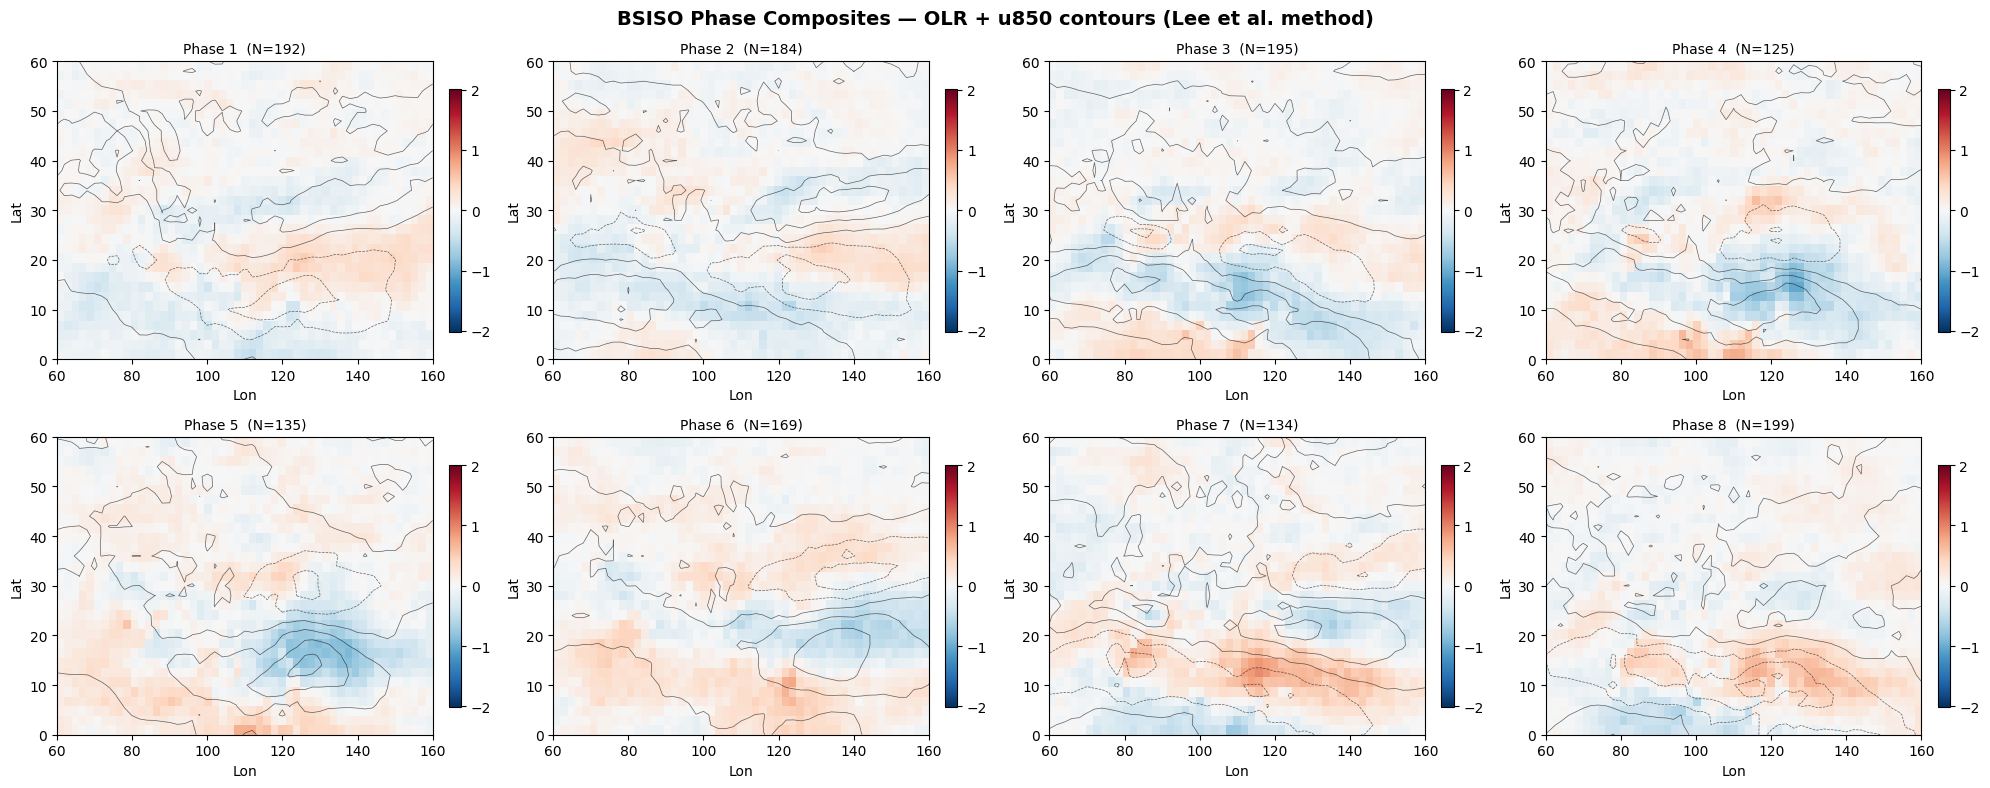

Saved: bsiso_phase_composites_lee.png


In [11]:
import matplotlib.pyplot as plt

phases  = sorted(df_aligned['bsiso_phase'].unique())
extent  = [lons.min(), lons.max(), lats.min(), lats.max()]
lim     = float(np.percentile(np.abs(X_lee[:, 2]), 95))

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('BSISO Phase Composites — OLR + u850 contours (Lee et al. method)',
             fontsize=14, fontweight='bold')

for ax, phase in zip(axes.flat, phases):
    idx      = df_aligned[df_aligned['bsiso_phase'] == phase].index.values
    olr_comp = X_lee[idx, 2].mean(axis=0)
    u_comp   = X_lee[idx, 0].mean(axis=0)

    im = ax.imshow(olr_comp, cmap='RdBu_r', origin='upper',
                   extent=extent, aspect='auto', vmin=-lim, vmax=lim)
    ax.contour(lons, lats[::-1], u_comp[::-1],
               levels=5, colors='k', linewidths=0.5, alpha=0.6)
    ax.set_title(f'Phase {phase}  (N={len(idx)})', fontsize=10)
    ax.set_xlabel('Lon')
    ax.set_ylabel('Lat')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/bsiso_phase_composites_lee.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: bsiso_phase_composites_lee.png')

## Cell 12 — Verification: ENSO Composites

Expected after Lee et al. preprocessing: ENSO composites should be near-zero.
The 120-day running mean removes the slowly-varying ENSO background.
Any residual pattern reflects ENSO modulation of the intraseasonal variability —
exactly the signal the model is trying to learn.

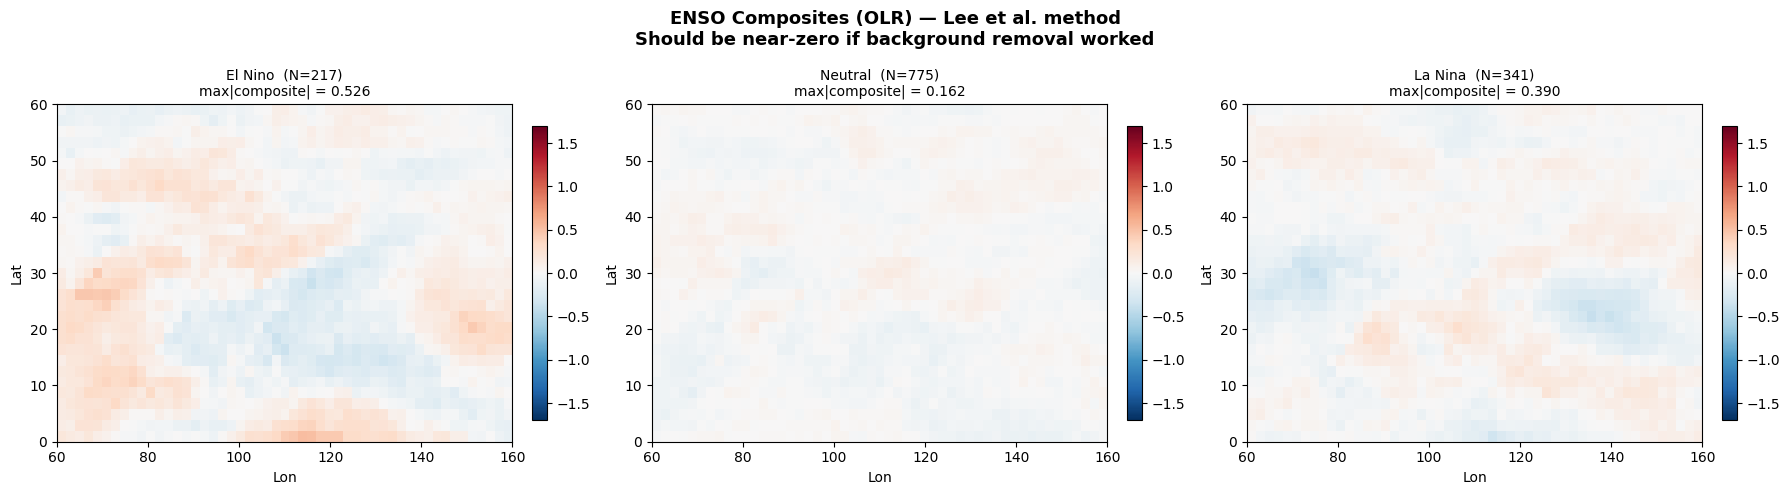

If max|composite| is near 0 -> background removed successfully.
If max|composite| is large  -> running mean window may be too short.


In [12]:
enso_cats = ['El Nino', 'Neutral', 'La Nina']
lim_enso  = float(np.percentile(np.abs(X_lee[:, 2]), 90))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ENSO Composites (OLR) — Lee et al. method\n'
             'Should be near-zero if background removal worked',
             fontsize=13, fontweight='bold')

for ax, cat in zip(axes, enso_cats):
    idx = df_aligned[df_aligned['enso_category'] == cat].index.values
    if len(idx) == 0:
        ax.set_title(f'{cat} — no data')
        continue
    olr_comp = X_lee[idx, 2].mean(axis=0)
    max_abs  = float(np.abs(olr_comp).max())

    im = ax.imshow(olr_comp, cmap='RdBu_r', origin='upper',
                   extent=extent, aspect='auto', vmin=-lim_enso, vmax=lim_enso)
    ax.set_title(f'{cat}  (N={len(idx)})\nmax|composite| = {max_abs:.3f}', fontsize=10)
    ax.set_xlabel('Lon')
    ax.set_ylabel('Lat')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/enso_composites_lee.png', dpi=100, bbox_inches='tight')
plt.show()
print('If max|composite| is near 0 -> background removed successfully.')
print('If max|composite| is large  -> running mean window may be too short.')

## Cell 13 — Summary Report

In [13]:
print('=' * 65)
print('PREPROCESSING SUMMARY — Lee et al. (2013) Method')
print('=' * 65)
print(f'Input data:           MJJAS ERA5 (May-Sep 1979-2023)')
print(f'Base period:          {BASE_START}-{BASE_END}')
print(f'Running mean window:  {WINDOW} days (preceding)')
print()
print('Steps applied:')
print('  1. Remove annual cycle  (daily climatology per DOY)')
print('  2. Remove interannual   (120-day running mean)')
print('  3. Normalize            (area-averaged temporal std)')
print()
print(f'Output array:  X_July_lee.npy  shape={X_lee.shape}  float32')
print(f'Labels:        labels_aligned_lee.csv  {len(df_aligned)} rows')
print()
print('Normalization scalars:')
print(f'  u850 std: {std_u:.4f} m/s')
print(f'  v850 std: {std_v:.4f} m/s')
print(f'  OLR  std: {std_olr:.4f} J/m2')
print()
print('Running mean window coverage for July:')
print('  Jul 01: ~61 days (51%)')
print('  Jul 15: ~75 days (63%)')
print('  Jul 31: ~91 days (76%)')
print('  Full 120-day window from ~Aug 29 onward')
print()
print('Next: run 04_training.ipynb with X_July_lee.npy')
print('=' * 65)

PREPROCESSING SUMMARY — Lee et al. (2013) Method
Input data:           MJJAS ERA5 (May-Sep 1979-2023)
Base period:          1981-2010
Running mean window:  120 days (preceding)

Steps applied:
  1. Remove annual cycle  (daily climatology per DOY)
  2. Remove interannual   (120-day running mean)
  3. Normalize            (area-averaged temporal std)

Output array:  X_July_lee.npy  shape=(1333, 3, 31, 51)  float32
Labels:        labels_aligned_lee.csv  1333 rows

Normalization scalars:
  u850 std: 4.5020 m/s
  v850 std: 3.8171 m/s
  OLR  std: 144683.7344 J/m2

Running mean window coverage for July:
  Jul 01: ~61 days (51%)
  Jul 15: ~75 days (63%)
  Jul 31: ~91 days (76%)
  Full 120-day window from ~Aug 29 onward

Next: run 04_training.ipynb with X_July_lee.npy


---
## Done!

Files on Google Drive:
```
BSISO_SSL_Project/data/processed/
  X_July_lee.npy              (N, 3, 31, 51) float32
  labels_aligned_lee.csv      N rows aligned to X_July_lee
  norm_stats_lee.json         area-averaged std per channel
  bsiso_phase_composites_lee.png
  enso_composites_lee.png
```
Next step: update 04_training.ipynb to load X_July_lee.npy.

---
*DDCS Project | jh9141@nyu.edu*